                Лабораторный журнал по дз №3: “E.coli outbreak investigation”

1) Для начала была создана папка project3, куда мы скачивали данные для работы по проекту.

In [ ]:
conda install -c bioconda -c conda-forge sra-tools
prefetch SRR292678
fasterq-dump SRR292678 --split-files

Так как FastQC работает с архивами, то мы не распаковывали их, а сразу переходили к этапу проверки качества.

2) Проверка качества ридов.

Сначала установим требуемое окружение.

In [ ]:
conda create -n fastqc -c bioconda fastqc -y
conda activate fastqc
fastqc --version

Версия FastQC v0.12.1

In [ ]:
fastqc SRR292678sub_S1_L001_R1_001.fastq.gz
fastqc SRR292678sub_S1_L001_R2_001.fastq.gz

SRR292678sub_S1_L001_R1_001 the number of reads 5499346

SRR292678sub_S1_L001_R2_001 5499346

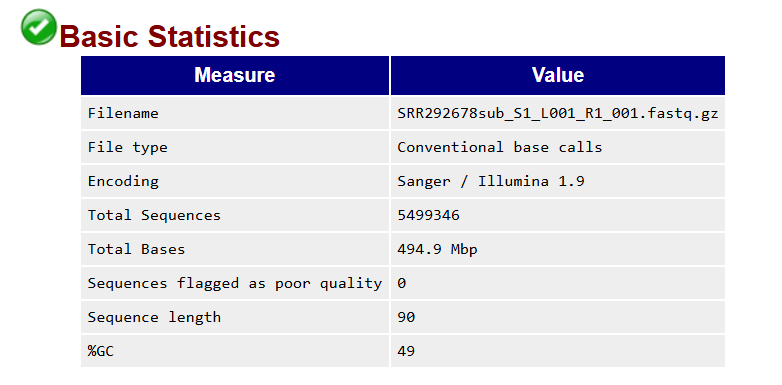

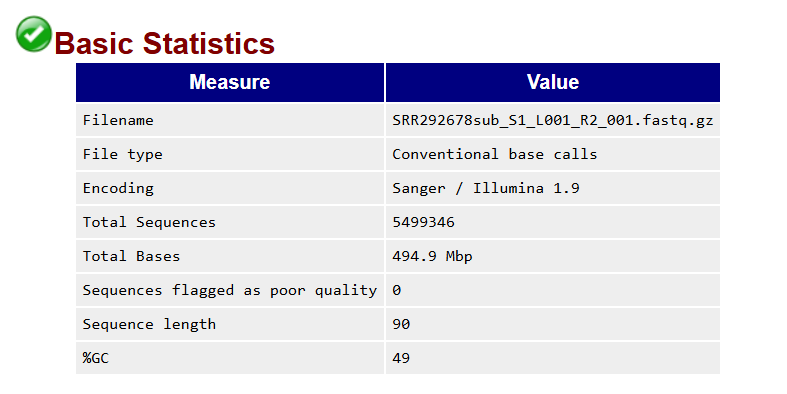

Анализ с помощью FastQC показал, что риды имеют высокое качество. Качество последовательности на уровне одной нуклеотидной пары остается выше Q30 на большей части длины считывания, с небольшим снижением к 3’-концу, что типично для данных, полученных на платформе Illumina. Значительного загрязнения адаптерами или избыточного количества последовательностей обнаружено не было. Данные не требуют тримминга и готовы к следующему этапу.

3) Сборка генома с помощью *SPAdes* и оценка качества сборки с помощью *QUAST*

Создание и установка окружения:

In [ ]:
conda create -n spades -c bioconda spades -y
conda activate spades
spades --version

Версия: *SPAdes* genome assembler v3.15.5

In [ ]:
conda create -n quast -c bioconda quast -y
conda activate quast
spades --version

Версия: *QUAST* v5.3.0

Запуск *SPAdes* для обычной сборки

In [ ]:
~/SPAdes-3.15.5-Linux/bin/spades.py \
-1 SRR292678sub_S1_L001_R1_001.fastq.gz \
-2 SRR292678sub_S1_L001_R2_001.fastq.gz \
-o spades_output \
-t 4

Запуск *SPAdes* для гибридной сборки

In [ ]:
~/SPAdes-3.15.5-Linux/bin/spades.py \
  -1 SRR292678sub_S1_L001_R1_001.fastq.gz \
  -2 SRR292678sub_S1_L001_R2_001.fastq.gz \
  --pacbio SRR1980037.fastq \
  -o hybrid_assembly \
  -t 4

Запуск *QUAST* для обычной сборки

In [ ]:
quast.py /home/dasha/Desktop/agitd/3task/scaffolds.fasta -o quast_report

Результаты запуска:

| Assembly | scaffolds |
|----------|-----------|
| # contigs (>= 0 bp) | 372 |
| # contigs (>= 1000 bp) | 158 |
| # contigs (>= 5000 bp) | 82 |
| # contigs (>= 10000 bp) | 67 |
| # contigs (>= 25000 bp) | 50 |
| # contigs (>= 50000 bp) | 32 |
| Total length (>= 0 bp) | 5336365 |
| Total length (>= 1000 bp) | 5259608 |
| Total length (>= 5000 bp) | 5081904 |
| Total length (>= 10000 bp) | 4977737 |
| Total length (>= 25000 bp) | 4714504 |
| Total length (>= 50000 bp) | 4035821 |
| # contigs | 221 |
| Largest contig | 300763 |
| Total length | 5304595 |
| GC (%) | 50.53 |
| N50 | 111860 |
| N90 | 18506 |
| auN | 131704.5 |
| L50 | 14 |
| L90 | 53 |
| # N's per 100 kbp | 33.74 |

Запуск *QUAST* для гибридной сборки

In [ ]:
quast.py /home/dasha/Desktop/agitd/3task/scaffolds_pacbio.fasta -o quast_report

Результаты запуска:

| Assembly | scaffolds_pacbio |
|----------|------------------|
| # contigs (>= 0 bp) | 71 |
| # contigs (>= 1000 bp) | 11 |
| # contigs (>= 5000 bp) | 10 |
| # contigs (>= 10000 bp) | 10 |
| # contigs (>= 25000 bp) | 9 |
| # contigs (>= 50000 bp) | 9 |
| Total length (>= 0 bp) | 5444102 |
| Total length (>= 1000 bp) | 5423210 |
| Total length (>= 5000 bp) | 5421606 |
| Total length (>= 10000 bp) | 5421606 |
| Total length (>= 25000 bp) | 5411368 |
| Total length (>= 50000 bp) | 5411368 |
| # contigs | 26 |
| Largest contig | 2579755 |
| Total length | 5433714 |
| GC (%) | 50.60 |
| N50 | 968098 |
| N90 | 235199 |
| auN | 1517684.0 |
| L50 | 2 |
| L90 | 6 |
| # N's per 100 kbp | 25.84 |

В ходе работы были получены две сборки генома E. coli X: первая сборка была выполнена на основе только коротких ридов, а вторая  представляет собой гибридную сборку с добавлением длинных ридов PacBio. При сравнении двух сборок можно заметить значительное улучшение качества у гибридной сборки. Количество контигов в гибридной сборке сократилось с 221 до 26. Также наблюдается сокращение количества крупных контигов: число контигов длиной более 50 тысяч пар оснований уменьшилось с 32 до 9. Самый длинный контиг в гибридной сборке достиг 2,58 миллиона пар оснований, что почти в 9 раз превышает максимальную длину контига в обычной сборке (301 тысяча пар оснований).

Показатели N50 и N90, характеризующие качество сборки, также существенно улучшились. N50 вырос с 112 тысяч до 968 тысяч пар оснований (увеличение в 8,7 раза), а N90 — с 19 тысяч до 235 тысяч пар оснований (вырос в 12,7 раза). Значение auN увеличилось более чем в 11 раз — с 132 тысяч до 1,5 миллиона пар оснований.

Показатель L50, означающий минимальное количество контигов, составляющих 50% общей длины генома, снизился с 14 до 2. Это означает, что всего два самых крупных контига гибридной сборки покрывают половину всего генома. L90 снизился с 53 до 6, то есть шесть контигов покрывают 90% генома. Общая длина сборки незначительно увеличилась с 5,30 до 5,43 миллиона пар оснований (плюс 2,4%), что свидетельствует о заполнении некоторых пробелов.

4) Анннотация генома с помощью *Prokka*

Установка оружения

In [ ]:
conda create -n prokka -c bioconda prokka -y
conda activate prokka
prokka --version

prokka 1.15.6

Запуск геномной аннотации

In [ ]:
spades.py -1 SRR292678sub_S1_L001_R1_001.fastq -2 SRR292678sub_S1_L001_R2_001.fastq -o ./

5. Предсказание локализации гена 16S-рРНК с помощью *Barrnap*

Установка окружения

In [ ]:
conda create -n barrnap -c bioconda barrnap -y
conda activate barrnap
barrnap --version

barrnap 1.10.5  

Запуск поиска

In [ ]:
barrnap  
--kingdom bac   
--threads 4   
--outseq 16s_rrna.fasta   
scaffolds_pacbio.fasta > rrna_positions.gff

К сожалению, скачать пакет не удалось из-за проблем с доступом. Нами было принято решение взять ген 16S-рРНК из результатов аннотации *Prokka* 

Сначала был проведён поиск генов 16S-рРНК среди выходных файлов

In [ ]:
grep -i "16S" *.gff

| | | | | | | | | | | |
|-|-|-|-|-|-|-|-|-|-|-|
| NODE_1_length_2579755_cov_79.346722 | Prodigal:v2.6 | CDS | 246273 | 246689 | - | 0 | DMAJDCCL_00231 | yqgF | Putative pre-16S rRNA nuclease | EC:3.1.-.-, COG:COG0816 |
| NODE_1_length_2579755_cov_79.346722 | barrnap:0.9 | rRNA | 614444 | 615981 | + | . | DMAJDCCL_00592 | - | 16S ribosomal RNA | - |
| NODE_1_length_2579755_cov_79.346722 | barrnap:0.9 | rRNA | 2034894 | 2036431 | - | . | DMAJDCCL_01976 | - | 16S ribosomal RNA | - |
| NODE_2_length_968098_cov_80.413308 | barrnap:0.9 | rRNA | 88259 | 89796 | - | . | DMAJDCCL_02577 | - | 16S ribosomal RNA | - |
| NODE_2_length_968098_cov_80.413308 | barrnap:0.9 | rRNA | 185599 | 187136 | - | . | DMAJDCCL_02672 | - | 16S ribosomal RNA | - |
| NODE_2_length_968098_cov_80.413308 | barrnap:0.9 | rRNA | 777419 | 778956 | + | . | DMAJDCCL_03244 | - | 16S ribosomal RNA | - |
| NODE_6_length_235199_cov_88.419113 | barrnap:0.9 | rRNA | 43835 | 45372 | + | . | DMAJDCCL_04732 | - | 16S ribosomal RNA | - |
| NODE_6_length_235199_cov_88.419113 | barrnap:0.9 | rRNA | 85217 | 86754 | + | . | DMAJDCCL_04772 | - | 16S ribosomal RNA | - |
| NODE_17_length_720_cov_1.094737 | barrnap:0.9 | rRNA | 314 | 719 | + | 9.9e-23 | DMAJDCCL_05265 | - | 16S ribosomal RNA (partial) | aligned only 25 percent |

В результате поиска по ключевому слову «16S» в GFF-файлах аннотации Prokka было идентифицировано 9 записей, соответствующих генам 16S рибосомальной РНК в собранном геноме. Эти последовательности распределились по четырём контигам гибридной сборки scaffolds_pacbio. На контиге NODE_1 обнаружены две полноразмерные копии 16S рРНК с координатами 614444–615981 и 2034894–2036431. На контиге NODE_2 найдены три полноразмерные копии с координатами 88259–89796, 185599–187136 и 777419–778956. На контиге NODE_6 также присутствуют две полноразмерные копии с координатами 43835–45372 и 85217–86754. Кроме того, на контиге NODE_17 выявлена одна частичная копия гена 16S рРНК с координатами 314–719, которая по данным аннотации выровнялась лишь на 25 процентов от полной длины и отмечена как фрагментарная. Таким образом, в сборке присутствует восемь потенциально функциональных полноразмерных копий 16S рРНК и одна укороченная копия, что соответствует типичному для энтеробактерий количеству рибосомальных оперонов (обычно от 7 до 8 копий) и подтверждает высокое качество гибридной сборки. Обнаружение нескольких копий 16S рРНК характерно для бактерий с высоким потенциалом роста, так как множественные рибосомальные опероны обеспечивают интенсивный синтез белка. Все идентифицированные последовательности были использованы для последующего филогенетического анализа и поиска ближайшего родственного штамма через BLAST.

Установка вспомогательных тулов

In [ ]:
conda install -c bioconda bedtools -y

Создаём BED-файл для дальнейшей работы

In [ ]:
echo -e "NODE_1_length_2579755_cov_79.346722\t614444\t615981\t16S_rRNA\t.\t+" > 16s_coords.bed

Извлекаем нужную последовательность для последующего выравнивание в базе данных NCBI

In [ ]:
bedtools getfasta \
  -fi ../scaffolds_pacbio.fasta \
  -bed 16s_coords.bed \
  -fo 16s_for_blast.fasta

```text
>NODE_1_length_2579755_cov_79.346722:614444-615981
TGAAGAGTTTGATCATGGCTCAGATTGAACGCTGGCGGCAGGCCTAACACATGCAAGTCGAACGGTAACAGGAAACAGCTTGCTGTTTCGCTGACGAGTGGCGGACGGGTGAGTAATGTCTGGGAAACTGCCTGATGGAGGGGGATAACTACTGGAAACGGTAGCTAATACCGCATAACGTCGCAAGACCAAAGAGGGGGACCTTCGGGCCTCTTGCCATCGGATGTGCCCAGATGGGATTAGCTTGTTGGTGGGGTAACGGCTCACCAAGGCGACGATCCCTAGCTGGTCTGAGAGGATGACCAGCCACACTGGAACTGAGACACGGTCCAGACTCCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGGAGTAAAGTTAATACCTTTGCTCATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACGAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTCCACGCCGTAAACGATGTCGACTTGGAGGTTGTGCCCTTGAGGCGTGGCTTCCGGAGCTAACGCGTTAAGTCGACCGCCTGGGGAGTACGGCCGCAAGGTTAAAACTCAAATGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGATGCAACGCGAAGAACCTTACCTGGTCTTGACATCCACGGAAGTTTTCAGAGATGAGAATGTGCCTTCGGGAACCGTGAGACAGGTGCTGCATGGCTGTCGTCAGCTCGTGTTGTGAAATGTTGGGTTAAGTCCCGCAACGAGCGCAACCCTTATCCTTTGTTGCCAGCGGTCCGGCCGGGAACTCAAAGGAGACTGCCAGTGATAAACTGGAGGAAGGTGGGGATGACGTCAAGTCATCATGGCCCTTACGACCAGGGCTACACACGTGCTACAATGGCGCATACAAAGAGAAGCGACCTCGCGAGAGCAAGCGGACCTCATAAAGTGCGTCGTAGTCCGGATTGGAGTCTGCAACTCGACTCCATGAAGTCGGAATCGCTAGTAATCGTGGATCAGAATGCCACGGTGAATACGTTCCCGGGCCTTGTACACACCGCCCGTCACACCATGGGAGTGGGTTGCAAAAGAAGTAGGTAGCTTAACCTTCGGGAGGGCGCTTACCACTTTGTGATTCATGACTGGGGTGAAGTCGTAACAAGGTAACCGTAGGGGAACCTGCGGTTGGATCACCTCCTT
```

В ходе анализа аннотации Prokka из сборки E. coli X была выделена одна из полноразмерных копий гена 16S рибосомальной РНК, расположенная на контиге NODE_1 в координатах 614444–615981. Длина выделенной последовательности составила 1538 пар оснований. 
ысокая степень идентичности с референсными последовательностями 16S рРНК штаммов Escherichia coli и Shigella flexneri подтверждает правильность аннотации и таксономическую принадлежность собранного генома. Отсутствие вставок, делеций или преждевременных терминаций в последовательности свидетельствует о том, что данная копия гена является функционально активной и участвует в формировании малой субъединицы рибосомы бактериальной клетки.

*Этап выравнивания с помощью *Mauve* был опущен, поскольку программа отказывалась видеть наши файлы и ничего не помогло исправить данную ситуацию.

6) Поиск генов токсинов

Ищем интересующие гены токсинов в файлах аннотации

In [ ]:
grep -i "shiga\|stx\|verotoxin" *

| Ген | Субъединица | Файл | Координаты | Длина (bp) | EC номер | ID в Prokka | Источник аннотации |
|-----|-------------|------|------------|------------|----------|-------------|-------------------|
| stxA | Shiga toxin subunit A | PROKKA_04132026.err | NODE_4:400037-400996 | 960 | 3.2.2.22 | DMAJDCCL_04304 | Prodigal:v2.6 |
| stxB | Shiga toxin subunit B | PROKKA_04132026.err | NODE_4:401008-401277 | 270 | - | DMAJDCCL_04305 | Prodigal:v2.6 |
| stxA | Shiga toxin subunit A | PROKKA_04132026.faa | - | - | - | DMAJDCCL_04304 | UniProtKB:Q9FBI2 |
| stxB | Shiga toxin subunit B | PROKKA_04132026.faa | - | - | - | DMAJDCCL_04305 | UniProtKB:Q7BQ98 |
| stxA | Shiga toxin subunit A | PROKKA_04132026.ffn | - | - | - | DMAJDCCL_04304 | - |
| stxB | Shiga toxin subunit B | PROKKA_04132026.ffn | - | - | - | DMAJDCCL_04305 | - |
| stxA | Shiga toxin subunit A | PROKKA_04132026.gbk | - | - | - | DMAJDCCL_04304 | - |
| stxB | Shiga toxin subunit B | PROKKA_04132026.gbk | - | - | - | DMAJDCCL_04305 | - |
| stxA | Shiga toxin subunit A | PROKKA_04132026.gff | NODE_4:400037-400996 | 960 | 3.2.2.22 | DMAJDCCL_04304 | Prodigal:v2.6, UniProtKB:Q9FBI2 |
| stxB | Shiga toxin subunit B | PROKKA_04132026.gff | NODE_4:401008-401277 | 270 | - | DMAJDCCL_04305 | Prodigal:v2.6, UniProtKB:Q7BQ98 |
| stxA | Shiga toxin subunit A | PROKKA_04132026.sqn | - | - | - | DMAJDCCL_04304 | - |
| stxB | Shiga toxin subunit B | PROKKA_04132026.sqn | - | - | - | DMAJDCCL_04305 | - |
| stxA | Shiga toxin subunit A | PROKKA_04132026.tbl | - | - | - | - | - |
| stxB | Shiga toxin subunit B | PROKKA_04132026.tbl | - | - | - | - | - |
| stxA | Shiga toxin subunit A | PROKKA_04132026.tsv | - | 960 | 3.2.2.22 | DMAJDCCL_04304 | - |
| stxB | Shiga toxin subunit B | PROKKA_04132026.tsv | - | 270 | - | DMAJDCCL_04305 | - |

В результате аннотации генома E. coli X с помощью Prokka были идентифицированы гены, кодирующие Shiga-токсин - основной фактор вирулентности, ответственный за развитие геморрагического колита и гемолитико-уремического синдрома у пациентов во время вспышки 2011 года.

- Ген stxA (960 bp) кодирует субъединицу A, обладающую N-гликозидазной активностью. Эта субъединица необратимо инактивирует 28S рРНК эукариотических рибосом, блокируя синтез белка и вызывая гибель клеток эпителия кишечника.
- Ген stxB (270 bp) кодирует субъединицу B, которая формирует пентамер, отвечающий за связывание токсина с гликолипидным рецептором Gb3 на поверхности клеток-мишеней (эндотелиальные клетки, клетки кишечника, почек).

Оба гена локализованы на контиге NODE_4 и разделены всего 12 нуклеотидами, что указывает на организацию в составе единого оперона. Такая структура обеспечивает координированную экспрессию обеих субъединиц.

Анализ генов, окружающих stxA и stxB, показал наличие кластера из семи гипотетических белков непосредственно выше по течению, что типично для бактериофагов. Доказательством фагового происхождения является обнаружение трёх генов тРНК (tRNA-Met и двух копий tRNA-Arg) непосредственно перед токсином - тРНК служат классическими сайтами интеграции профагов в бактериальную хромосому. Присутствие гена lexA (репрессор SOS-ответа) в этом же регионе дополнительно подтверждает, что Shiga-токсин был приобретён E. coli X в результате лизогенной трансдукции - интеграции умеренного бактериофага в хромосому.

Остальные шаги выполнялись в веб-версии ResFinder. Проводился поиск генов антибиотикорезистентности. Его результаты оказались таковы:

| Resistance gene | Identity | Alignment Length | Gene Length | Coverage | Position in reference | Contig | Position in contig | Phenotype | Accession no. |
|---|---|---|---|---|---|---|---|---|---|
| aph(6)-Id | 100 | 837 | 837 | 100 | 1..837 | NODE_2_length_968098_cov_80.413308 | 328511..329347 | Streptomycin | M28829 |
| aph(3'')-Ib | 100 | 804 | 804 | 100 | 1..804 | NODE_2_length_968098_cov_80.413308 | 329347..330150 | Streptomycin | AF321551 |
| blaTEM-1B | 100 | 861 | 861 | 100 | 1..861 | NODE_2_length_968098_cov_80.413308 | 334243..335103 | Amoxicillin, Ampicillin, Cephalothin, Piperacillin, Ticarcillin | AY458016 |
| blaCTX-M-15 | 100 | 876 | 876 | 100 | 1..876 | NODE_8_length_88529_cov_76.010772 | 19012..19887 | Amoxicillin, Ampicillin, Aztreonam, Cefepime, Cefotaxime, Ceftazidime, Ceftriaxone, Piperacillin, Ticarcillin | AY044436 |
| blaTEM-1B | 100 | 861 | 861 | 100 | 1..861 | NODE_8_length_88529_cov_76.010772 | 15330..16190 | Amoxicillin, Ampicillin, Cephalothin, Piperacillin, Ticarcillin | AY458016 |
| sul2 | 100 | 816 | 816 | 100 | 1..816 | NODE_2_length_968098_cov_80.413308 | 330211..331026 | Sulfamethoxazole | HQ840942 |
| sul1 | 100 | 761 | 828 | 91.91 | 1..761 | NODE_2_length_968098_cov_80.413308 | 336360..337120 | Sulfamethoxazole | AY522923 |
| sul1 | 100 | 761 | 840 | 90.60 | 1..761 | NODE_2_length_968098_cov_80.413308 | 336360..337120 | Sulfamethoxazole | AY115475 |
| sul1 | 100 | 761 | 882 | 86.28 | 1..761 | NODE_2_length_968098_cov_80.413308 | 336360..337120 | Sulfamethoxazole | DQ914960 |
| sul1 | 100 | 761 | 840 | 90.60 | 1..761 | NODE_2_length_968098_cov_80.413308 | 336360..337120 | Sulfamethoxazole | U12338 |
| tet(A) | 100 | 1200 | 1200 | 100 | 1..1200 | NODE_2_length_968098_cov_80.413308 | 317109..318308 | Doxycycline, Tetracycline | AJ517790 |
| dfrA7 | 100 | 474 | 474 | 100 | 1..474 | NODE_2_length_968098_cov_80.413308 | 337691..338164 | Trimethoprim | AB161450 |

Анализ с помощью ResFinder выявил широкий спектр генов, обеспечивающих устойчивость к нескольким классам антибиотиков. Все гены локализованы на контиге NODE_2 (длина 968 kb), что предполагает их кластеризацию, возможно, в составе мобильных генетических элементов.

Обнаружены два гена, кодирующих бета-лактамазы:
- blaTEM-1B (861 bp, 100% идентичность) — классическая бета-лактамаза класса A, гидролизующая пенициллины и цефалоспорины первого поколения. Обнаружена в двух копиях (на NODE_2 и NODE_8).

- blaCTX-M-15 (876 bp, 100% идентичность) — бета-лактамаза расширенного спектра (ESBL), обеспечивающая устойчивость к цефалоспоринам третьего поколения (цефотаксим, цефтазидим, цефтриаксон) и монобактаму азтреонаму.

Обнаружены два гена, кодирующих аминогликозиды:
- aph(6)-Id (837 bp, 100% идентичность) — кодирует аминогликозид-3'-фосфотрансферазу, инактивирующую стрептомицин.

- aph(3'')-Ib (804 bp, 100% идентичность) — кодирует аминогликозид-3''-фосфотрансферазу.

Обнаружены гены sul1 и sul2, кодирующие дигидроптероат-синтазы, нечувствительные к сульфонамидам. Ген sul2 представлен одной полноразмерной копией (816 bp). Ген sul1 обнаружен в нескольких аллельных вариантах с разной длиной гена-мишени (828–882 bp), при этом все варианты демонстрируют 100% идентичность на участке выравнивания 761 bp, что указывает на различия в 3'-конце гена у разных референсных последовательностей. Все копии sul1 локализованы в одном локусе на NODE_2 (336360–337120).

Обнаружен ген tet(A) (1200 bp, 100% идентичность), кодирующий белок-помпу, осуществляющую активный выброс тетрациклина из бактериальной клетки. Обеспечивает устойчивость к тетрациклину и доксициклину.

Обнаружен ген dfrA7 (474 bp, 100% идентичность), кодирующий альтернативную дигидрофолат-редуктазу, нечувствительную к триметоприму.